**PARTICULA SOMETIDA A UN CAMPO ELECTRICO -$\alpha$ EN UN POZO DE POTENCIAL INFINITO**



La ecuación de Schrödinger en 1D es $-\frac{\hbar^2}{2m} \frac{d^2 \psi}{dx^2} + q\epsilon x\psi = E \psi$.

In [120]:
# Tensorflow Keras and rest of the packages
import tensorflow as tf
import keras as keras
from tensorflow.keras import models,Model
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
import scipy
from scipy.special import airy

In [121]:
plt.rcParams.update({
    'font.size': 14,           # Tamaño base de la fuente
    'axes.labelsize': 16,      # Tamaño de las etiquetas de los ejes (xlabel, ylabel)
    'axes.titlesize': 18,      # Tamaño del título de la gráfica
    'xtick.labelsize': 14,     # Tamaño de los números de la escala X
    'ytick.labelsize': 14,     # Tamaño de los números de la escala Y
    'legend.fontsize': 14,     # Tamaño del texto de la leyenda
    'figure.titlesize': 20     # Tamaño del título general de la figura (si usas suptitle)
})

In [122]:
def nn_model(activation,neurons_layer,n_layers):
    input=Input(shape=(neurons_layer[0],))
    x=input
    for hidden_layer_neurons in neurons_layer[1:-1]: 
        x=Dense(hidden_layer_neurons,activation=activation)(x)
    output=Dense(neurons_layer[n_layers-1])(x)
    return input,output

In [123]:
@keras.saving.register_keras_serializable()#Esto hace que se pueda guardar el modelo y cargarlo sin problemas despues
class EVE_PINN(tf.keras.Model):# Esta clase va a heredar de la clase Model de Keras, lo que nos permite usar todos los metodos de la clase Model y ademas definir nuestros propios metodos
    def set_step_dx(self,dx): #Este metodo inicializa la clase
      self.dx=dx #Lo que hace esto es que al objeto que luego instanciamos le asigna el atributo dx, que va a ser espaciado entre puntos
    
    def parameters(self,eps):
        self.eps=eps

    def set_L_a(self,L):
        self.L=L
        self.a=L/2

    def train_step(self, data):#Metodo que tiene internamente la clase Model del API de Keras
        x, y_exact = data

        # Use only for run_eagerly=True
        #pi = tf.constant(np.pi)
        #M0 = tf.square(pi)

        #Change initial conditions for the PINN
        x0 = tf.constant([-self.a], dtype=tf.float32)
        xL = tf.constant([self.a], dtype=tf.float32) # We consider L=1
        y0_exact = tf.constant([0.0], dtype=tf.float32)
        yL_exact = tf.constant([0.0], dtype=tf.float32)
        xi = tf.reshape(x,(x.shape[0],1))#Reconversion del batch de entrada a un vector columna, para que sea coherente con la salida en columna que devuelve self(xi)
        unit = tf.constant(1.0, dtype=tf.float32)
        unit = tf.reshape(unit,shape=xi[0].shape)

        # Spatial mesh
        dx = tf.constant(self.dx,dtype=tf.float32)

        with tf.GradientTape() as tape:
            y0=self(x0,training=False)
            yL=self(xL,training=False)
            # Calculate the second derivative dy2/dx2
            with tf.GradientTape() as tape1:
                tape1.watch(xi)
                with tf.GradientTape() as tape2:
                    tape2.watch(xi)#Watch le dice en que tensor se tiene que fijar para los calculos, aqui le decimos que mire el batch de entrada porque luego lo utilizamos para calcular la salida, esto es asi porque tape solo se fija en tensores variables y xi es constante 
                    y_NN = self(xi,training=False)#Cálculo de la y_NN para todos los datos, self(xi) hace el paso hacia delante del batch de entrada, y multplicamos por x*(1-x) para asegurar que la salida cumple las condiciones de contorno. Training=false porque esto solo sirve para calcular la funcion de perdida, es decir, estamos haciendo un predict de los datos xi de entrada
                    print(y_NN.shape)#Esto devolvera cual es el tamaño de la salida, que sera de otro vector columna, cada elemento la salida de cada dato de entrada del batch
                    tape2.watch(y_NN)#Ahora que esta calculada la salida, nos fijamos en el tensor de salida, de forma que ya podremos hacer la derivada
                dy_dx_NN = tape2.gradient(y_NN, xi)#Calcula la derivada de la salida respecto a la entrada, nos devolvera otro vector
                tape1.watch(y_NN)#De nuevo, se tiene que fijar
                tape1.watch(dy_dx_NN)#...
            d2y_dx2_NN = tf.squeeze(tape1.gradient(dy_dx_NN, xi))#Segunda derivada
            y_NN = tf.squeeze(y_NN)#Squeeze elimina las dimensiones de tamaño a 1 en los tensores, osea si tenemos un vector que seria un tensor de shape(y,1) al hacer squeeze pasa a ser solo de shape(y,), que es un vector fila 
            xi=tf.squeeze(xi)
            tape.watch(xi)
            tape.watch(y_NN)
            tape.watch(dy_dx_NN)
            tape.watch(d2y_dx2_NN)

            
            S_y_NN=-d2y_dx2_NN+y_NN*xi*self.eps
            num = tf.reduce_sum(y_NN*S_y_NN)#Esto es el producto escalar de y con la segunda derivada de y, no se multiplica por dx porque se va a ir luego al ser un cociente num/den
            den = tf.reduce_sum(tf.square(y_NN)) #Norma al cuadrado de y
            M = num/den #Funcion que cuando sea minima coincida con el autoestado fundamental
            M = tf.reshape(M,shape=(1,))#Reconvertimos en tensor de tamaño 0 porque era un esacalar, a un tensor de tamaño, que solo tiene un elemento que es el escalar.

            I = tf.reduce_sum(tf.square(y_NN))*dx
            I = tf.reshape(I,shape=(1,))# tensor que es la morma al cuadrado multiplicada por el factor dx de discretizacion, tambien es de dimension 1 con el reshape

            #Loss= ODE+ boundary/initial conditions
            lossDE = self.compiled_loss(S_y_NN, M*y_NN) #Esta loss lo que tiene interesante es que self.compiled_loss va a recibir como primer argumento el valor real bueno, y como segundo al valor predicho. Luego, cuando llamamos al metodo compile y le pasamos que tipo de metrica queremos, hara cuentas con ello
            loss =lossDE+100*self.compiled_loss(I,unit)+50*self.compiled_loss(y0,y0_exact)+50*self.compiled_loss(yL,yL_exact)# Esta loss es el autovalor mas la condicion de normalizacion, esta es con la que entrenamos

        gradients = tape.gradient(loss, self.trainable_weights)#Calcula la derivada de la funcion de perdida respecto a los parametros entrenables
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))#Zip empareja cada derivada de la lista gradientes con el parametro respecto al que se ha derivad0, de forma que le pasamos este tensor al optimizador que aplicara los gradientes y actualiza los parametros
        self.compiled_metrics.update_state(y_exact, y_NN)#Por ultimo, se actualiza el estado respecto al paso anterior con la y_NN calculada en este nuevo paso con los parametros anteriores
        metrics = {m.name: m.result() for m in self.metrics}#Dado que entiendo que el metodo self.compiled_metrics.updatestate actualiza las metricas como atributo del objeto en self.metrics. {} Crea un diccionario, en el que el formato_:_ indica clave:valor asociado 
        metrics['DE']=lossDE
        metrics['loss']=loss
        metrics['I']=I
        metrics['E']=M
        metrics['y0']=y0
        metrics['yL']=yL
        return metrics#Este diccionario creado que devuelve el metodo traning_step es el que utiliza model.fit para calcular las metricas

In [124]:
## Custom metric
@keras.saving.register_keras_serializable()#La serializamos para que despues al cargar el modelo, no tengamos que haber definido previamente la funcion, simplemente la habra guardado ya.
def mse_odd_even_sol(y_true, y_pred):
    return tf.minimum(tf.reduce_mean(tf.square(y_pred - y_true)),tf.reduce_mean(tf.square(y_pred + y_true)))#Devuelve el minimo entre y_NN con +-y_real 

dx= 0.02040816326530612
      converged: True
           flag: converged
 function_calls: 43
     iterations: 41
           root: 7.25049702515571
         method: bisect


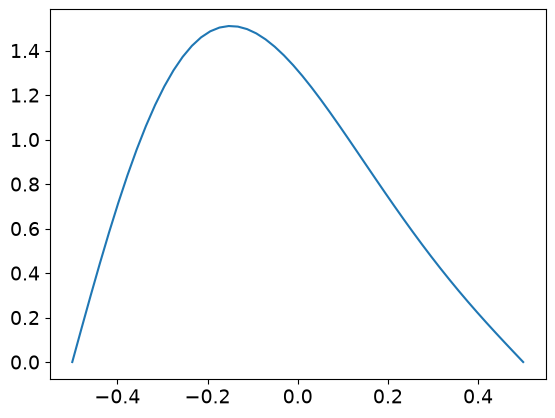

In [125]:
n_train = 50  # 500 for Sergio's estimation, 10 for Javi's
L=1
# Avoid the boundaries: ¿derivaties ill-defined at the boundaries?
xmin = -L/2 #xmin que no es cero, es cero mas un delta
xmax = L/2 
# Definition of the function domain
x_train,step_dx = np.linspace(xmin,xmax,n_train,retstep=True)#No se coge ni el cero ni el uno porque los hemos forzad a ser cero al multiplicar por x*(1-x) a la yNN
print("dx=",step_dx)

#Physic's parameters
eps=50
alpha=np.pow(eps,1/3)

# The solution y(x) for training and validation datasets

def determinante(E):
    z0=-alpha*(L/2+E/eps)
    zL=alpha*(L/2-E/eps)
    Ai0,_,Bi0,_=airy(z0)
    AiL,_,BiL,_=airy(zL)
    det=Ai0*BiL-AiL*Bi0
    return det
#print(determinante(4), determinante (7))
E=scipy.optimize.root_scalar(determinante,bracket=[6,10],method='bisect')
print(E)
#Cte de integracion
z=alpha*(x_train-E.root/eps)
Ai,_,Bi,_=airy(z)
I=tf.reduce_sum((Ai-Ai[0]/Bi[0]*Bi)**2)*step_dx
C=1/np.sqrt(I)
y_train_fund=C*(Ai-Ai[0]/Bi[0]*Bi)
plt.plot(x_train,y_train_fund)



In [126]:
print("x(0)=",x_train[0])
print("y(0)=",y_train_fund[0])

# Input and output neurons (from the data)
neurons_layer=[1, 50, 50, 50,1]
n_layers=5


# Define the model
activation = 'tanh'
input,output = nn_model(activation,neurons_layer,n_layers)

model = EVE_PINN(input,output)
model.set_step_dx(step_dx)
model.parameters(eps)
model.set_L_a(L)
#Define the metrics, optimizer and loss
metrics=[mse_odd_even_sol] #tf.keras.metrics.MeanSquaredError()
lr=0.001
optimizer = Adam(learning_rate=lr)

model.compile(loss='mse',
          optimizer=optimizer,
          metrics=metrics, run_eagerly=False)

model.summary()

x(0)= -0.5
y(0)= 0.0


Model: "eve_pinn_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
# Build the model
checkpoint_callback = ModelCheckpoint(
    filepath=f"Res_Campo_E_fund_L_{L}_n_{n_train}_eps_{eps}.weights.h5",
    monitor="mse_odd_even_sol",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1,
)#Esto hace que cuando se lo pasemos a model.fit nos guarde solo los parametros del modelo en variacional_E_fundamental.h5 siempre que la perdida sea menor que en la anterior epoca
csv_logger =tf.keras.callbacks.CSVLogger(f'metricas_Res_E_fund_L_{L}_n_{n_train}.csv', append=False)

In [ ]:
epochs = 2000 # 5000        
history = model.fit(x_train, y_train_fund, batch_size=n_train, epochs=epochs,
                  callbacks=[checkpoint_callback,csv_logger])#Evidentemente sin validacion, tamaño del batch=n_train, cada batch es una epoca 

Epoch 1/2000
(50, 1)


c:\Users\ruben\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:696: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
c:\Users\ruben\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:671: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


(50, 1)


In [74]:
name=f'Res_Campo_E_fund_L_{L}_n_{n_train}_eps_{eps}.keras'
model.save(name)

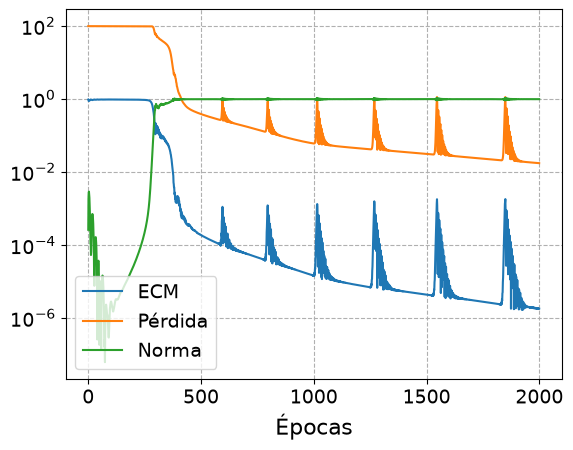

In [75]:
plt.plot(history.history['mse_odd_even_sol'],label='ECM')
plt.plot(history.history['loss'],label='Pérdida')
plt.plot(history.history['I'],label= 'Norma')
#plt.title('Método variacional pozo infinito')
plt.xlabel('Épocas')
plt.yscale("log")
plt.grid(True, linestyle="--")
plt.legend()
Imagen_metricas=f'Métricas_Campo_E_fund_L_{L}_n_{n_train}_eps_{eps}'
plt.savefig(Imagen_metricas, dpi=300, bbox_inches='tight')


In [76]:
input,output = nn_model(activation,neurons_layer,n_layers)

cloned_model = EVE_PINN(input,output)
cloned_model.set_step_dx(step_dx)
model.set_L_a(L)
#Define the metrics, optimizer and loss
#metrics = [mse_odd_even_sol] #tf.keras.metrics.MeanSquaredError()

cloned_model.compile(loss='mse',
          optimizer=optimizer,
          run_eagerly=False)
cloned_model.load_weights(f"C:\TFG\PINNS\PINNS\Pozo_infinito_Campo\Residuo\Res_Campo_E_fund_L_{L}_n_{n_train}_eps_{eps}.weights.h5")

In [77]:
y_NN_cloned_model=cloned_model.predict(x_train)
y_NN_cloned_model=np.reshape(y_NN_cloned_model,x_train.shape)
y_NN=model.predict(x_train)
y_NN=np.reshape(y_NN,n_train)
y=y_NN
y_best=y_NN_cloned_model

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


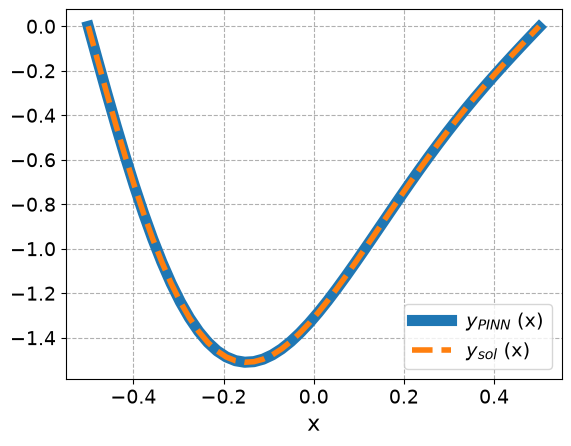

In [80]:
#plt.plot(x_train,y,lw=8,label=r'$y_{PINN}$ (x)')
plt.plot(x_train,y_best,lw=8,label=r'$y_{PINN}$ (x)')
plt.plot(x_train,-y_train_fund, lw=4, linestyle='--',label=r'$y_{sol}$ (x)')
#plt.title('Método variacional pozo infinito')
plt.xlabel('x')
plt.grid(True, linestyle="--")
plt.legend()
Imagen_y_NN=f'Res_Campo_E_fund_L_{L}_n_{n_train}_eps_{eps}'
plt.savefig(Imagen_y_NN, dpi=300, bbox_inches='tight')

In [58]:
print(history.history['E'][epochs-1])

[7.2454076]


**FIRST_EXCITED**

In [115]:
@keras.saving.register_keras_serializable()#Esto hace que se pueda guardar el modelo y cargarlo sin problemas despues
class EVE_PINN(tf.keras.Model):# Esta clase va a heredar de la clase Model de Keras, lo que nos permite usar todos los metodos de la clase Model y ademas definir nuestros propios metodos
    #def fi_0(self,fi_0):
        self.fi_0=fi_0
        
    def set_step_dx(self,dx): #Este metodo inicializa la clase
      self.dx=dx #Lo que hace esto es que al objeto que luego instanciamos le asigna el atributo dx, que va a ser espaciado entre puntos
    
    def parameters(self,eps):
        self.eps=eps
        
    def set_L_a(self,L):
        self.L=L
        self.a=L/2

    def train_step(self, data):#Metodo que tiene internamente la clase Model del API de Keras
        x, y_exact = data


        #Change initial conditions for the PINN
        x0 = tf.constant([-self.a], dtype=tf.float32)
        xL = tf.constant([self.a], dtype=tf.float32) # We consider L=1
        y0_exact = tf.constant([0.0], dtype=tf.float32)
        yL_exact = tf.constant([0.0], dtype=tf.float32)
        xi = tf.reshape(x,(x.shape[0],1))#Reconversion del batch de entrada a un vector columna, para que sea coherente con la salida en columna que devuelve self(xi)
        unit = tf.constant(1.0, dtype=tf.float32)
        unit = tf.reshape(unit,shape=xi[0].shape)
        #Converting the dtype of fi_0 to float32
        #fi_0=tf.constant(self.fi_0,dtype=tf.float32)
        print(fi_0.shape)

        # Spatial mesh
        dx = tf.constant(self.dx,dtype=tf.float32)

        with tf.GradientTape() as tape:
            y0=self(x0,train=False)
            yL=self(xL,train=False)
            # Calculate the second derivative dy2/dx2
            with tf.GradientTape() as tape1:
                tape1.watch(xi)
                with tf.GradientTape() as tape2:
                    tape2.watch(xi)#Watch le dice en que tensor se tiene que fijar para los calculos, aqui le decimos que mire el batch de entrada porque luego lo utilizamos para calcular la salida, esto es asi porque tape solo se fija en tensores variables y xi es constante 
                    y_NN =self(xi,training=False)#Cálculo de la y_NN para todos los datos, self(xi) hace el paso hacia delante del batch de entrada, y multplicamos por x*(1-x) para asegurar que la salida cumple las condiciones de contorno. Training=false porque esto solo sirve para calcular la funcion de perdida, es decir, estamos haciendo un predict de los datos xi de entrada
                    print(y_NN.shape)#Esto devolvera cual es el tamaño de la salida, que sera de otro vector columna, cada elemento la salida de cada dato de entrada del batch
                    tape2.watch(y_NN)#Ahora que esta calculada la salida, nos fijamos en el tensor de salida, de forma que ya podremos hacer la derivada
                dy_dx_NN = tape2.gradient(y_NN, xi)#Calcula la derivada de la salida respecto a la entrada, nos devolvera otro vector
                tape1.watch(y_NN)#De nuevo, se tiene que fijar
                tape1.watch(dy_dx_NN)#...
            d2y_dx2_NN = tf.squeeze(tape1.gradient(dy_dx_NN, xi))#Segunda derivada
            y_NN = tf.squeeze(y_NN)#Squeeze elimina las dimensiones de tamaño a 1 en los tensores, osea si tenemos un vector que seria un tensor de shape(y,1) al hacer squeeze pasa a ser solo de shape(y,), que es un vector fila 
            tape.watch(xi)
            tape.watch(y_NN)
            tape.watch(dy_dx_NN)
            tape.watch(d2y_dx2_NN)

            
            S_y_NN=-d2y_dx2_NN+y_NN*xi*self.eps
            num = tf.reduce_sum(y_NN*S_y_NN)#Esto es el producto escalar de y con la segunda derivada de y, no se multiplica por dx porque se va a ir luego al ser un cociente num/den
            den = tf.reduce_sum(tf.square(y_NN)) # Could this be zero? #Norma al cuadrado de y
            M = num/den #Funcion que cuando sea minima coincida con el autoestado fundamental
            M = tf.reshape(M,shape=(1,))#Reconvertimos en tensor de tamaño 0 porque era un esacalar, a un tensor de tamaño, que solo tiene un elemento que es el escalar.

            I = tf.reduce_sum(tf.square(y_NN))*dx
            I = tf.reshape(I,shape=(1,))# tensor que es la morma al cuadrado multiplicada por el factor dx de discretizacion, tambien es de dimension 1 con el reshape

            H = tf.constant(0.0,dtype=tf.float32)
            num_1=tf.reduce_sum(y_NN*fi_0)**2
            den_1=tf.reduce_sum(tf.square(y_NN))*tf.reduce_sum(tf.square(fi_0))
            Schwartz=num_1/den_1
            Schwartz=tf.reshape(Schwartz,shape=xi[0].shape)

            #Loss= ODE+ boundary/initial conditions
            lossDE = self.compiled_loss(S_y_NN, M*y_NN) #Esta loss lo que tiene interesante es que self.compiled_loss va a recibir como primer argumento el valor real bueno, y como segundo al valor predicho. Luego, cuando llamamos al metodo compile y le pasamos que tipo de metrica queremos, hara cuentas con ello
            loss = lossDE + 100*self.compiled_loss(I,unit)+50*self.compiled_loss(y0,y0_exact)+50*self.compiled_loss(yL,yL_exact)# Esta loss es el autovalor mas la condicion de normalizacion, esta es con la que entrenamos

        gradients = tape.gradient(loss, self.trainable_weights)#Calcula la derivada de la funcion de perdida respecto a los parametros entrenables
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))#Zip empareja cada derivada de la lista gradientes con el parametro respecto al que se ha derivad0, de forma que le pasamos este tensor al optimizador que aplicara los gradientes y actualiza los parametros
        self.compiled_metrics.update_state(y_exact, y_NN)#Por ultimo, se actualiza el estado respecto al paso anterior con la y_NN calculada en este nuevo paso con los parametros anteriores
        metrics = {m.name: m.result() for m in self.metrics}#Dado que entiendo que el metodo self.compiled_metrics.updatestate actualiza las metricas como atributo del objeto en self.metrics. {} Crea un diccionario, en el que el formato_:_ indica clave:valor asociado 
        metrics['DE']=lossDE
        metrics['loss']=loss
        metrics['I']=I
        metrics['E']=M
        metrics['y0']=y0
        metrics['yL']=yL
        return metrics#Este diccionario creado que devuelve el metodo traning_step es el que utiliza model.fit para calcular las metricas

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 6)

In [102]:
@keras.saving.register_keras_serializable()#Esto hace que se pueda guardar el modelo y cargarlo sin problemas despues
class EVE_PINN(tf.keras.Model):# Esta clase va a heredar de la clase Model de Keras, lo que nos permite usar todos los metodos de la clase Model y ademas definir nuestros propios metodos
    def set_step_dx(self,dx): #Este metodo inicializa la clase
      self.dx=dx #Lo que hace esto es que al objeto que luego instanciamos le asigna el atributo dx, que va a ser espaciado entre puntos
    
    def parameters(self,eps):
        self.eps=eps

    def set_L_a(self,L):
        self.L=L
        self.a=L/2

    def train_step(self, data):#Metodo que tiene internamente la clase Model del API de Keras
        x, y_exact = data


        #Change initial conditions for the PINN
        x0 = tf.constant([-self.a], dtype=tf.float32)
        xL = tf.constant([self.a], dtype=tf.float32) # We consider L=1
        y0_exact = tf.constant([0.0], dtype=tf.float32)
        yL_exact = tf.constant([0.0], dtype=tf.float32)
        xi = tf.reshape(x,(x.shape[0],1))#Reconversion del batch de entrada a un vector columna, para que sea coherente con la salida en columna que devuelve self(xi)
        unit = tf.constant(1.0, dtype=tf.float32)
        unit = tf.reshape(unit,shape=xi[0].shape)

        # Spatial mesh
        dx = tf.constant(self.dx,dtype=tf.float32)

        with tf.GradientTape() as tape:
            y0=self(x0,training=False)
            yL=self(xL,training=False)
            # Calculate the second derivative dy2/dx2
            with tf.GradientTape() as tape1:
                tape1.watch(xi)
                with tf.GradientTape() as tape2:
                    tape2.watch(xi)#Watch le dice en que tensor se tiene que fijar para los calculos, aqui le decimos que mire el batch de entrada porque luego lo utilizamos para calcular la salida, esto es asi porque tape solo se fija en tensores variables y xi es constante 
                    y_NN = self(xi,training=False)#Cálculo de la y_NN para todos los datos, self(xi) hace el paso hacia delante del batch de entrada, y multplicamos por x*(1-x) para asegurar que la salida cumple las condiciones de contorno. Training=false porque esto solo sirve para calcular la funcion de perdida, es decir, estamos haciendo un predict de los datos xi de entrada
                    print(y_NN.shape)#Esto devolvera cual es el tamaño de la salida, que sera de otro vector columna, cada elemento la salida de cada dato de entrada del batch
                    tape2.watch(y_NN)#Ahora que esta calculada la salida, nos fijamos en el tensor de salida, de forma que ya podremos hacer la derivada
                dy_dx_NN = tape2.gradient(y_NN, xi)#Calcula la derivada de la salida respecto a la entrada, nos devolvera otro vector
                tape1.watch(y_NN)#De nuevo, se tiene que fijar
                tape1.watch(dy_dx_NN)#...
            d2y_dx2_NN = tf.squeeze(tape1.gradient(dy_dx_NN, xi))#Segunda derivada
            y_NN = tf.squeeze(y_NN)#Squeeze elimina las dimensiones de tamaño a 1 en los tensores, osea si tenemos un vector que seria un tensor de shape(y,1) al hacer squeeze pasa a ser solo de shape(y,), que es un vector fila 
            xi=tf.squeeze(xi)
            tape.watch(xi)
            tape.watch(y_NN)
            tape.watch(dy_dx_NN)
            tape.watch(d2y_dx2_NN)

            
            S_y_NN=-d2y_dx2_NN+y_NN*xi*self.eps
            num = tf.reduce_sum(y_NN*S_y_NN)#Esto es el producto escalar de y con la segunda derivada de y, no se multiplica por dx porque se va a ir luego al ser un cociente num/den
            den = tf.reduce_sum(tf.square(y_NN)) #Norma al cuadrado de y
            M = num/den #Funcion que cuando sea minima coincida con el autoestado fundamental
            M = tf.reshape(M,shape=(1,))#Reconvertimos en tensor de tamaño 0 porque era un esacalar, a un tensor de tamaño, que solo tiene un elemento que es el escalar.

            I = tf.reduce_sum(tf.square(y_NN))*dx
            I = tf.reshape(I,shape=(1,))# tensor que es la morma al cuadrado multiplicada por el factor dx de discretizacion, tambien es de dimension 1 con el reshape

            #Loss= ODE+ boundary/initial conditions
            lossDE = self.compiled_loss(S_y_NN, M*y_NN) #Esta loss lo que tiene interesante es que self.compiled_loss va a recibir como primer argumento el valor real bueno, y como segundo al valor predicho. Luego, cuando llamamos al metodo compile y le pasamos que tipo de metrica queremos, hara cuentas con ello
            loss =lossDE+100*self.compiled_loss(I,unit)+50*self.compiled_loss(y0,y0_exact)+50*self.compiled_loss(yL,yL_exact)# Esta loss es el autovalor mas la condicion de normalizacion, esta es con la que entrenamos

        gradients = tape.gradient(loss, self.trainable_weights)#Calcula la derivada de la funcion de perdida respecto a los parametros entrenables
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))#Zip empareja cada derivada de la lista gradientes con el parametro respecto al que se ha derivad0, de forma que le pasamos este tensor al optimizador que aplicara los gradientes y actualiza los parametros
        self.compiled_metrics.update_state(y_exact, y_NN)#Por ultimo, se actualiza el estado respecto al paso anterior con la y_NN calculada en este nuevo paso con los parametros anteriores
        metrics = {m.name: m.result() for m in self.metrics}#Dado que entiendo que el metodo self.compiled_metrics.updatestate actualiza las metricas como atributo del objeto en self.metrics. {} Crea un diccionario, en el que el formato_:_ indica clave:valor asociado 
        metrics['DE']=lossDE
        metrics['loss']=loss
        metrics['I']=I
        metrics['E']=M
        metrics['y0']=y0
        metrics['yL']=yL
        return metrics#Este diccionario creado que devuelve el metodo traning_step es el que utiliza model.fit para calcular las metricas

dx= 0.02040816326530612
      converged: True
           flag: converged
 function_calls: 41
     iterations: 39
           root: 40.177003160193635
         method: bisect


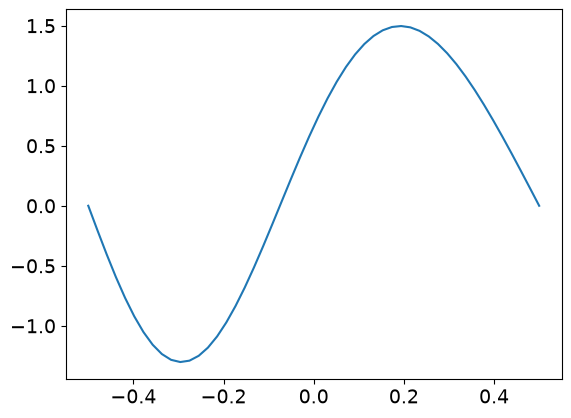

In [116]:
n_train = 50 
L=1
# Avoid the boundaries: ¿derivaties ill-defined at the boundaries?
xmin = -L/2
xmax = L/2  
# Definition of the function domain
x_train,step_dx = np.linspace(xmin,xmax,n_train,retstep=True)#No se coge ni el cero ni el uno porque los hemos forzado a ser cero al multiplicar por x*(1-x) a la yNN
print("dx=",step_dx)

#Physic's parameters
eps=50
alpha=np.pow(eps,1/3)

# The solution y(x) for training and validation datasets

def determinante(E):
    z0=-alpha*(L/2+E/eps)
    zL=alpha*(L/2-E/eps)
    Ai0,_,Bi0,_=airy(z0)
    AiL,_,BiL,_=airy(zL)
    det=Ai0*BiL-AiL*Bi0
    return det

E=scipy.optimize.root_scalar(determinante,bracket=[40,41],method='bisect')
print(E)
#Cte de integracion
z=alpha*(x_train-E.root/eps)
Ai,_,Bi,_=airy(z)
I=tf.reduce_sum((Ai-Ai[0]/Bi[0]*Bi)**2)*step_dx
C=1/np.sqrt(I)
y_train_exc=C*(Ai-Ai[0]/Bi[0]*Bi)
plt.plot(x_train,y_train_exc,label='first excited')


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


Model: "eve_pinn_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,251 (20.51 KB)

 Trainable params: 5,251 (20.51 KB)

 Non-trainable params: 0 (0.00 B)

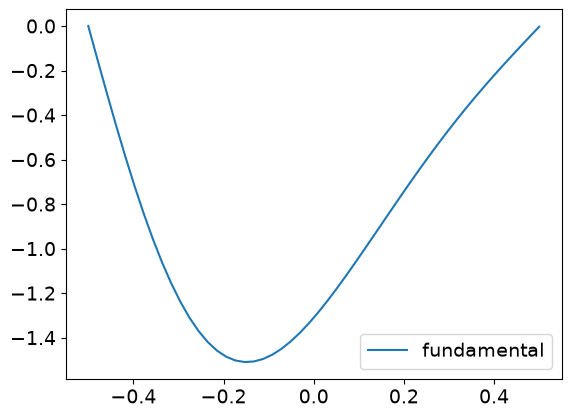

In [117]:
# Input and output neurons (from the data)
neurons_layer=[1, 50, 50, 50,1]
n_layers=5

#load model fundamental state
name="C:\TFG\PINNS\PINNS\Pozo_infinito_Campo\Residuo\Fundamental\Res_Campo_E_fund_L_1_n_50_eps_50.keras"
fund_model_Campo=keras.models.load_model(name)
y_NN_0=fund_model_Campo.predict(x_train)
y_NN_0=np.reshape(y_NN_0,n_train)
fi_0=y_NN_0
plt.plot(x_train, fi_0,label='fundamental')
plt.legend()

# Define the model
activation = 'tanh'
input,output = nn_model(activation,neurons_layer,n_layers)
model = EVE_PINN(input,output)
model.set_step_dx(step_dx)
#model.fi_0(fi_0)
model.parameters(eps)
model.set_L_a(L)
#Define the metrics, optimizer and loss
metrics = [mse_odd_even_sol] #tf.keras.metrics.MeanSquaredError()
lr=0.001
optimizer = Adam(learning_rate=lr)

model.compile(loss='mse',
          optimizer=optimizer,
          metrics=metrics, run_eagerly=False)

model.summary()

In [118]:
# Build the model
checkpoint_callback = ModelCheckpoint(
    filepath=f"Res_Campo_E_exc_L_{L}_n_{n_train}_eps_{eps}.weights.h5",
    monitor="mse_odd_even_sol",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1,
)#Esto hace que cuando se lo pasemos a model.fit nos guarde solo los parametros del modelo en variacional_E_fundamental.h5 siempre que la perdida sea menor que en la anterior epoca
csv_logger =tf.keras.callbacks.CSVLogger(f'metricas_Res_E_exc_L_{L}_n_{n_train}.csv', append=False)

In [119]:
epochs = 2000 # 5000        
history = model.fit(x_train, y_train_exc, batch_size=n_train, epochs=epochs,
                  callbacks=[checkpoint_callback,csv_logger])#Evidentemente sin validacion, tamaño del batch=n_train, cada batch es una epoca 

Epoch 1/2000


TypeError: Expected float32, but got <bound method EVE_PINN.fi_0 of <EVE_PINN name=eve_pinn_20, built=True>> of type 'method'.

In [72]:
name=f'Res_Campo_E_exc_L_{L}_n_{n_train}_eps_{eps}.keras'
model.save(name)

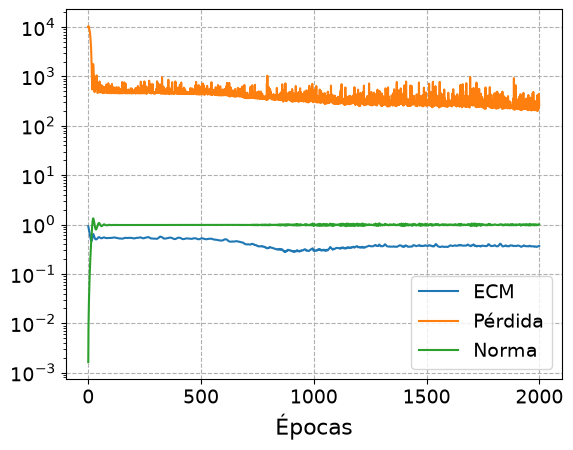

In [73]:
plt.plot(history.history['mse_odd_even_sol'],label='ECM')
plt.plot(history.history['loss'],label='Pérdida')
plt.plot(history.history['I'],label= 'Norma')
#plt.title('Método variacional pozo infinito')
plt.xlabel('Épocas')
plt.yscale("log")
plt.grid(True, linestyle="--")
plt.legend()
Imagen_metricas=f'Métricas_Res_Campo_E_fund_L_{L}_n_{n_train}_eps_{eps}'
plt.savefig(Imagen_metricas, dpi=300, bbox_inches='tight')

In [74]:
input,output = nn_model(activation,neurons_layer,n_layers)

cloned_model = EVE_PINN(input,output)
cloned_model.load_weights(f"C:\TFG\PINNS\PINNS\Pozo_infinito_Campo\Residuo\Res_Campo_E_exc_L_{L}_n_{n_train}_eps_{eps}.weights.h5")

In [75]:
y_NN_cloned_model=cloned_model.predict(x_train)
y_NN_cloned_model=np.reshape(y_NN_cloned_model,x_train.shape)
y_NN=model.predict(x_train)
y_NN=np.reshape(y_NN,n_train)
y=y_NN
y_best=y_NN_cloned_model

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step 


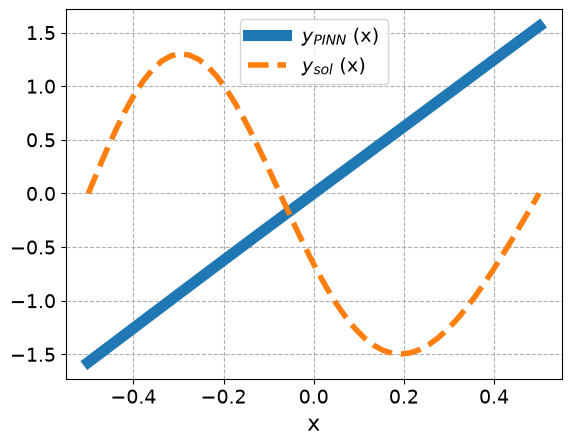

In [76]:
plt.plot(x_train,y,lw=8,label=r'$y_{PINN}$ (x)')
#plt.plot(x_train,y_best,lw=8,label=r'$y_{PINN}$ (x)')
plt.plot(x_train,-y_train_exc, lw=4, linestyle='--',label=r'$y_{sol}$ (x)')
#plt.title('Método variacional pozo infinito')
plt.xlabel('x')
plt.grid(True, linestyle="--")
plt.legend()
Imagen_y_NN=f'Campo_E_exc_L_{L}_n_{n_train}_eps_{eps}'
plt.savefig(Imagen_y_NN, dpi=300, bbox_inches='tight')